In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip -q install requests beautifulsoup4 pandas openpyxl lxml
import requests
import re
import time
import pandas as pd
from bs4 import BeautifulSoup
from urllib.robotparser import RobotFileParser

base_url = "https://www.zappos.com"
category_url = "https://www.zappos.com/running-shoes"
robots_url = f"{base_url}/robots.txt"

rp = RobotFileParser()
rp.set_url(robots_url)
rp.read()
print("Kategori sayfası robots.txt tarafından erişilebilir mi? :", rp.can_fetch("*", category_url))

Kategori sayfası robots.txt tarafından erişilebilir mi? : True


In [4]:
headers = {"User-Agent": "Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)"}
response = requests.get(category_url, headers=headers, timeout=15)
soup = BeautifulSoup(response.text, "lxml")

product_links = []
for a in soup.find_all("a"):
    text = a.get_text(" ", strip=True)
    if "Brand Name" in text and "Price" in text:
        href = a.get("href")
        full_url = href if href.startswith("http") else f"{base_url}{href}"
        product_links.append({"text": text, "url": full_url})

print("Bulunan ürün linkleri:", len(product_links))

Bulunan ürün linkleri: 100


In [5]:
import re

def parse_product_text(text):


    brand = None
    m = re.search(r"Brand Name (.*?) Product Name", text)
    if m:
        brand = m.group(1).strip()



    title = None
    m = re.search(r"Product Name (.*?) (Gender|Color|Price)", text)
    if m:
        title = m.group(1).strip()



    price = None
    m = re.search(r"Price \$([0-9.]+)", text)
    if m:
        price = float(m.group(1))



    msrp = None
    m = re.search(r"MSRP:\s*\$([0-9.]+)", text)
    if m:
        msrp = float(m.group(1))



    rating = None
    m = re.search(r"Rating\s+([0-9]+)", text)
    if m:
        rating = int(m.group(1))


    return brand, title, price, msrp, rating

In [6]:
products = []
max_records = 100
for item in product_links[:max_records]:
    brand, title, price, msrp, rating = parse_product_text(item["text"])
    products.append({
        "brand": brand,
        "title": title,
        "price_usd": price,
        "msrp_usd": msrp,
        "rating": rating,
        "url": item["url"]
    })
    time.sleep(1)
df = pd.DataFrame(products)

print("Çekilen veri sayısı:", len(df))
df.head()

Çekilen veri sayısı: 100


,brand,title,price_usd,msrp_usd,rating,url
0,Ryka,Devotion Swift Running Sneaker,99.99,NaN,3.0,https://www.zappos.com/p/ryka-devotion-swift-r...
1,On,Cloud Play (Little Kid),100.00,NaN,4.0,https://www.zappos.com/p/on-kids-cloud-play-li...
2,Saucony,Cohesion TR14 LTT Trail Running Shoe (Little K...,34.16,60.0,4.0,https://www.zappos.com/p/saucony-kids-cohesion...
3,adidas,adiZero Evo SL Running Shoes,149.95,NaN,5.0,https://www.zappos.com/p/adidas-adizero-evo-sl...
4,adidas,Supernova Rise 3 Running Shoes,119.00,140.0,3.0,https://www.zappos.com/p/adidas-supernova-rise...


In [7]:
df.to_csv("running_shoes_zappos.csv", index=False, encoding="utf-8-sig")
df.to_excel("running_shoes_zappos.xlsx", index=False)
print("Dosyalar kaydedildi.")

Dosyalar kaydedildi.


In [8]:
print(product_links[1]["text"])

Brand Name On Product Name Cloud Play (Little Kid) Color Arctic/Ivory Price $100 Rating 4 Rated 4 stars out of 5 ( 47 )


In [9]:
df_clean = df.copy()

print("Veri boyutu:", df_clean.shape)
print("\nEksik veri sayıları:")
print(df_clean.isna().sum())

Veri boyutu: (100, 6)

Eksik veri sayıları:
brand         0
title         0
price_usd     0
msrp_usd     60
rating       23
url           0
dtype: int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   brand      100 non-null    object 
 1   title      100 non-null    object 
 2   price_usd  100 non-null    float64
 3   msrp_usd   40 non-null     float64
 4   rating     77 non-null     float64
 5   url        100 non-null    object 
dtypes: float64(3), object(3)
memory usage: 4.8+ KB


In [11]:
df = df.rename(columns={
    "brand": "marka",
    "title": "model",
    "price_usd": "fiyat ($)",
    "msrp_usd": "net fiyat ($)",
    "rating": "skor",
    "url": "ürün linki"
})

In [12]:
df.columns

Index(['marka', 'model', 'fiyat ($)', 'net fiyat ($)', 'skor', 'ürün linki'], dtype='object')

In [13]:
print("Doldurmadan önce:")
print(df[["net fiyat ($)", "skor"]].isnull().sum())


msrp_ortalama = df["net fiyat ($)"].mean()
rating_ortalama = df["skor"].mean()


df["net fiyat ($)"] = df["net fiyat ($)"].fillna(msrp_ortalama)
df["skor"] = df["skor"].fillna(rating_ortalama)


df.loc[
    df["net fiyat ($)"] < df["fiyat ($)"],
    "net fiyat ($)"
] = df["fiyat ($)"]


print("\nDoldurduktan sonra:")
print(df[["net fiyat ($)", "skor"]].isnull().sum())


negatif_kontrol = (
    (df["net fiyat ($)"] - df["fiyat ($)"]) < 0
).sum()

print("\nNegatif indirim sayısı:", negatif_kontrol)

Doldurmadan önce:
net fiyat ($)    60
skor             23
dtype: int64

Doldurduktan sonra:
net fiyat ($)    0
skor             0
dtype: int64

Negatif indirim sayısı: 0


In [14]:
df.head()

,marka,model,fiyat ($),net fiyat ($),skor,ürün linki
0,Ryka,Devotion Swift Running Sneaker,99.99,127.54775,3.0,https://www.zappos.com/p/ryka-devotion-swift-r...
1,On,Cloud Play (Little Kid),100.00,127.54775,4.0,https://www.zappos.com/p/on-kids-cloud-play-li...
2,Saucony,Cohesion TR14 LTT Trail Running Shoe (Little K...,34.16,60.00000,4.0,https://www.zappos.com/p/saucony-kids-cohesion...
3,adidas,adiZero Evo SL Running Shoes,149.95,149.95000,5.0,https://www.zappos.com/p/adidas-adizero-evo-sl...
4,adidas,Supernova Rise 3 Running Shoes,119.00,140.00000,3.0,https://www.zappos.com/p/adidas-supernova-rise...


In [15]:
df["model"].unique()

array(['Devotion Swift Running Sneaker', 'Cloud Play (Little Kid)',
       'Cohesion TR14 LTT Trail Running Shoe (Little Kid/Big Kid)',
       'adiZero Evo SL Running Shoes', 'Supernova Rise 3 Running Shoes',
       'Rave Run v2 (Little Kid)',
       'adiZero Evo SL Running Shoes (Big Kid)', 'Anthem 8', 'Antora 4',
       'Ultraboost 5', 'Adizero Boston 13 Running Shoes',
       'Response 2 Running Shoes', 'Darter Pro 2 Fade Running Shoes',
       'Velocity Nitro 4 Running Shoes',
       'Foreverrun Nitro 2 Running Shoes', 'Ultraboost 5X Running Shoes',
       'Ascend Running Shoes (Big Kid)', 'Magnify Nitro™ 3 Running Shoes',
       'Darter Pro 2 Running Shoes', 'Ascend Running Shoes', 'Lancer Run',
       'Run Falcon 5', 'Go Run Consistent 2.0 Mile',
       'Fresh Foam Arishi v4 GTX®',
       'Cohesion TR14 A/C Trail Running Shoes (Little Kid/Big Kid)',
       'Adizero Adios Pro 4 Running Shoes', 'Max Run Vorteza',
       'Softride One4All Slip-On Shoes (Little Kid)',
       'One 4 A

In [16]:
df["model"] = (
    df["model"]
    .str.split(",").str[0]
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.strip()
)

In [17]:
df.head()

,marka,model,fiyat ($),net fiyat ($),skor,ürün linki
0,Ryka,Devotion Swift Running Sneaker,99.99,127.54775,3.0,https://www.zappos.com/p/ryka-devotion-swift-r...
1,On,Cloud Play,100.00,127.54775,4.0,https://www.zappos.com/p/on-kids-cloud-play-li...
2,Saucony,Cohesion TR14 LTT Trail Running Shoe,34.16,60.00000,4.0,https://www.zappos.com/p/saucony-kids-cohesion...
3,adidas,adiZero Evo SL Running Shoes,149.95,149.95000,5.0,https://www.zappos.com/p/adidas-adizero-evo-sl...
4,adidas,Supernova Rise 3 Running Shoes,119.00,140.00000,3.0,https://www.zappos.com/p/adidas-supernova-rise...


In [18]:
print("Tekrar temizliği öncesi kayıt sayısı:", len(df))

df = df.drop_duplicates()

print("Tekrar temizliği sonrası kayıt sayısı:", len(df))

Tekrar temizliği öncesi kayıt sayısı: 100
Tekrar temizliği sonrası kayıt sayısı: 100


In [19]:
excel_dosya_adi = "web_scraping.xlsx"

df.to_excel(excel_dosya_adi, index=False)

print("Excel dosyası oluşturuldu:", excel_dosya_adi)

Excel dosyası oluşturuldu: web_scraping.xlsx


In [20]:
from google.colab import files

files.download("web_scraping.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df.columns

Index(['marka', 'model', 'fiyat ($)', 'net fiyat ($)', 'skor', 'ürün linki'], dtype='object')

In [23]:
df = df.drop(columns=["ürün linki"])

df.head()

,marka,model,fiyat ($),net fiyat ($),skor
0,Ryka,Devotion Swift Running Sneaker,99.99,127.54775,3.0
1,On,Cloud Play,100.00,127.54775,4.0
2,Saucony,Cohesion TR14 LTT Trail Running Shoe,34.16,60.00000,4.0
3,adidas,adiZero Evo SL Running Shoes,149.95,149.95000,5.0
4,adidas,Supernova Rise 3 Running Shoes,119.00,140.00000,3.0


In [24]:
import pandas as pd
import matplotlib.pyplot as plt


df["indirim_miktarı ($)"] = df["net fiyat ($)"] - df["fiyat ($)"]

df["indirim_oranı (%)"] = (
    df["indirim_miktarı ($)"] / df["net fiyat ($)"] * 100
).round(2)

df.head()

,marka,model,fiyat ($),net fiyat ($),skor,indirim_miktarı ($),indirim_oranı (%)
0,Ryka,Devotion Swift Running Sneaker,99.99,127.54775,3.0,27.55775,21.61
1,On,Cloud Play,100.00,127.54775,4.0,27.54775,21.60
2,Saucony,Cohesion TR14 LTT Trail Running Shoe,34.16,60.00000,4.0,25.84000,43.07
3,adidas,adiZero Evo SL Running Shoes,149.95,149.95000,5.0,0.00000,0.00
4,adidas,Supernova Rise 3 Running Shoes,119.00,140.00000,3.0,21.00000,15.00


        fiyat ($)  net fiyat ($)  indirim_miktarı ($)  indirim_oranı (%)
count  100.000000     100.000000           100.000000         100.000000
mean   133.719800     147.609385            13.889585          10.734800
std     51.731861      47.563594            19.038130          14.088344
min     34.160000      48.000000             0.000000           0.000000
25%     93.750000     127.547750             0.000000           0.000000
50%    137.475000     149.950000             6.900000           8.435000
75%    169.950000     170.000000            21.750000          15.012500
max    280.000000     350.000000            72.557750          56.890000


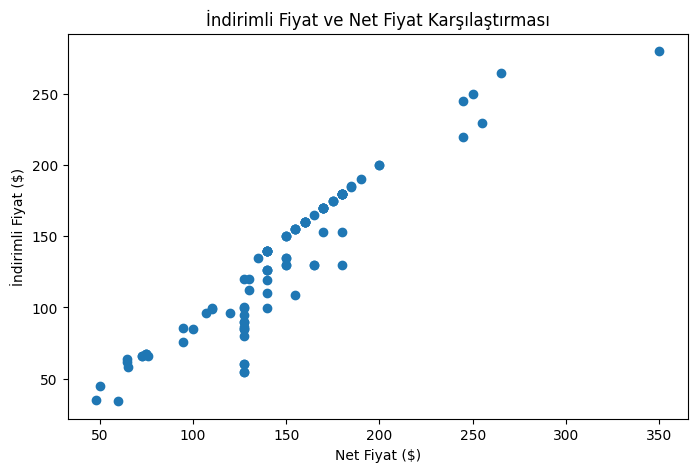

In [25]:
print(df[["fiyat ($)", "net fiyat ($)", "indirim_miktarı ($)", "indirim_oranı (%)"]].describe())

plt.figure(figsize=(8, 5))
plt.scatter(df["net fiyat ($)"], df["fiyat ($)"])
plt.xlabel("Net Fiyat ($)")
plt.ylabel("İndirimli Fiyat ($)")
plt.title("İndirimli Fiyat ve Net Fiyat Karşılaştırması")
plt.show()

In [26]:
marka_fiyat = df.groupby("marka")[["fiyat ($)", "net fiyat ($)"]].mean().sort_values("fiyat ($)", ascending=False)

marka_fiyat

,fiyat ($),net fiyat ($)
marka,,
Athletic Propulsion Labs (APL),248.143333,280.000000
Mizuno,190.000000,190.000000
La Sportiva,185.000000,185.000000
TYR,180.000000,180.000000
ECCO,174.950000,174.950000
Craft,166.666667,166.666667
Altra,166.616667,166.616667
On,165.968000,171.477550
Topo Athletic,153.975000,162.475000


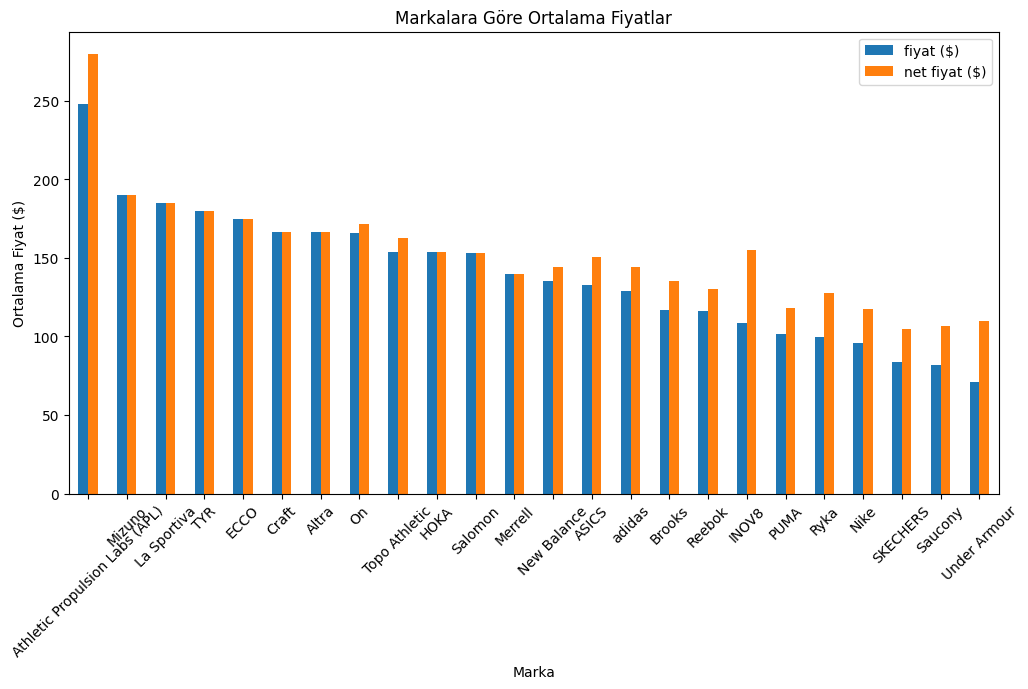

In [27]:
marka_fiyat.plot(kind="bar", figsize=(12, 6))

plt.title("Markalara Göre Ortalama Fiyatlar")
plt.xlabel("Marka")
plt.ylabel("Ortalama Fiyat ($)")
plt.xticks(rotation=45)
plt.show()

In [28]:
marka_skor = df.groupby("marka")["skor"].mean().sort_values(ascending=False)

marka_skor

,skor
marka,
La Sportiva,5.000000
Under Armour,4.645022
ASICS,4.142857
adidas,4.046953
Merrell,4.000000
Brooks,4.000000
TYR,4.000000
Nike,4.000000
New Balance,3.994589


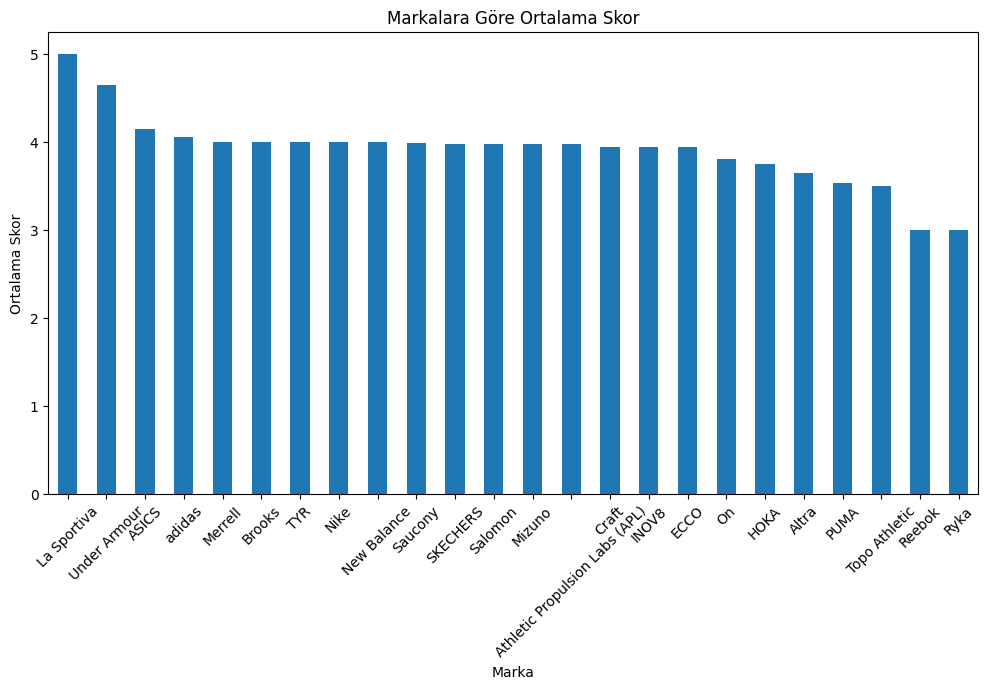

In [29]:
marka_skor.plot(kind="bar", figsize=(12, 6))

plt.title("Markalara Göre Ortalama Skor")
plt.xlabel("Marka")
plt.ylabel("Ortalama Skor")
plt.xticks(rotation=45)
plt.show()

In [30]:
korelasyon = df[["fiyat ($)", "skor"]].corr()

korelasyon

,fiyat ($),skor
fiyat ($),1.000000,0.007537
skor,0.007537,1.000000


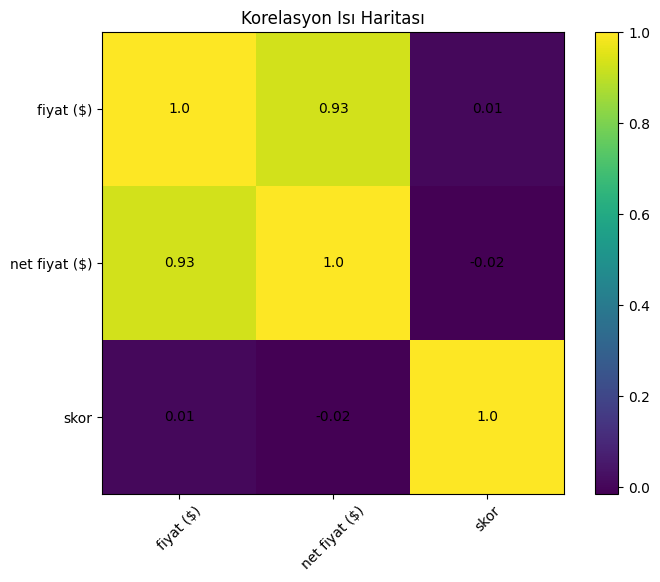

In [36]:
import matplotlib.pyplot as plt

korelasyon = df[["fiyat ($)", "net fiyat ($)", "skor"]].corr()

plt.figure(figsize=(8,6))

plt.imshow(korelasyon)

plt.xticks(range(len(korelasyon.columns)), korelasyon.columns, rotation=45)
plt.yticks(range(len(korelasyon.columns)), korelasyon.columns)

for i in range(len(korelasyon)):
    for j in range(len(korelasyon.columns)):
        plt.text(
            j,
            i,
            round(korelasyon.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.colorbar()

plt.title("Korelasyon Isı Haritası")

plt.show()

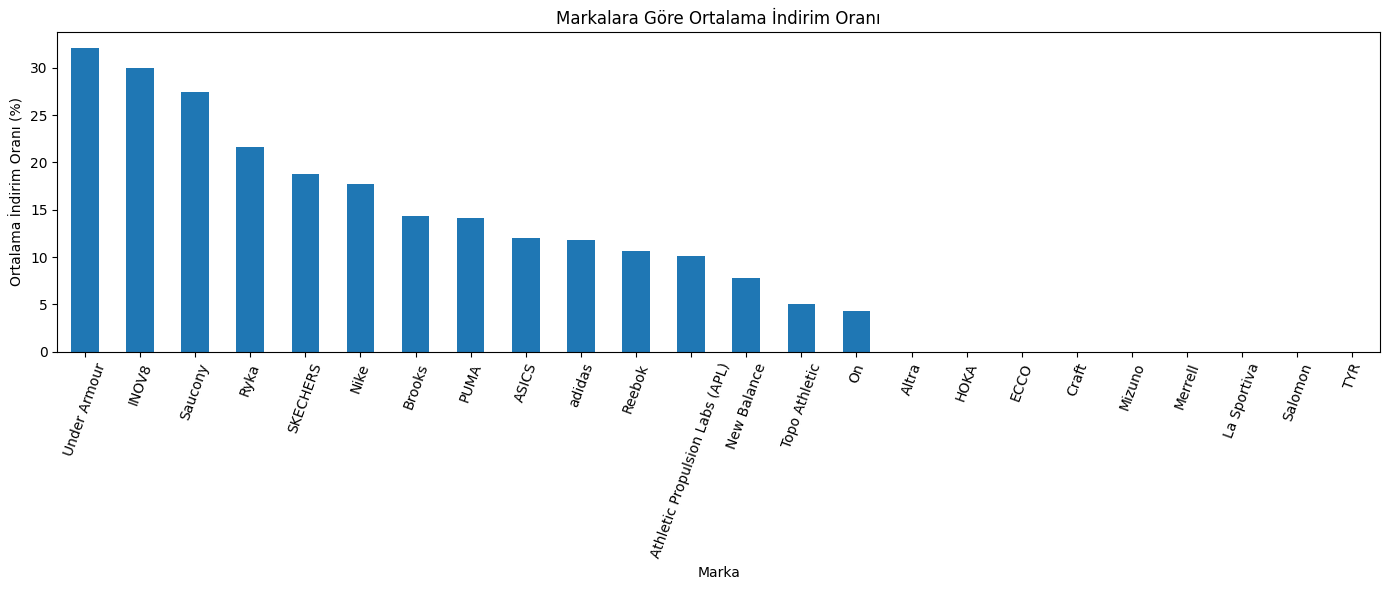

In [35]:
marka_indirim = df.groupby("marka")["indirim_oranı (%)"].mean().sort_values(ascending=False)

marka_indirim.plot(kind="bar", figsize=(14, 6))

plt.title("Markalara Göre Ortalama İndirim Oranı")
plt.xlabel("Marka")
plt.ylabel("Ortalama İndirim Oranı (%)")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

In [34]:
df["indirim_durumu"] = df["indirim_oranı (%)"].apply(
    lambda x: "İndirimli" if x > 0 else "İndirimsiz"
)

indirim_skor = df.groupby("indirim_durumu")["skor"].mean()

indirim_skor

,skor
indirim_durumu,
İndirimli,3.909091
İndirimsiz,3.965556


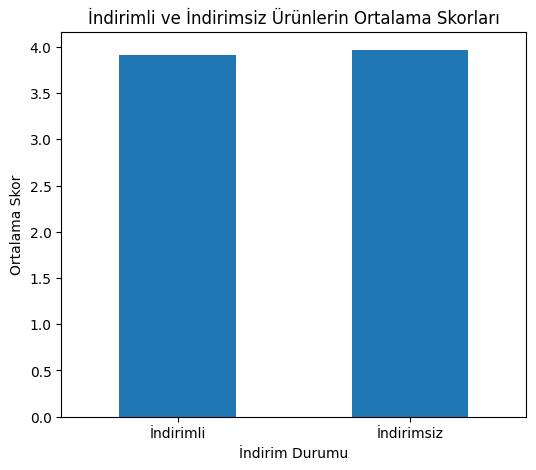

In [37]:
indirim_skor.plot(kind="bar", figsize=(6, 5))

plt.title("İndirimli ve İndirimsiz Ürünlerin Ortalama Skorları")
plt.xlabel("İndirim Durumu")
plt.ylabel("Ortalama Skor")
plt.xticks(rotation=0)
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

X = df[["marka", "net fiyat ($)", "skor"]]

y = df["fiyat ($)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_features = ["marka"]
numeric_features = ["net fiyat ($)", "skor"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])


model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print("R2 Skoru:", round(r2_score(y_test, y_pred), 2))

MAE: 10.21
RMSE: 14.33
R2 Skoru: 0.89


In [39]:
yeni_urun = pd.DataFrame({
    "marka": ["Nike"],
    "net fiyat ($)": [150],
    "skor": [4.5]
})

tahmin = model.predict(yeni_urun)

print("Tahmin edilen fiyat:", round(tahmin[0], 2), "$")

Tahmin edilen fiyat: 141.1 $


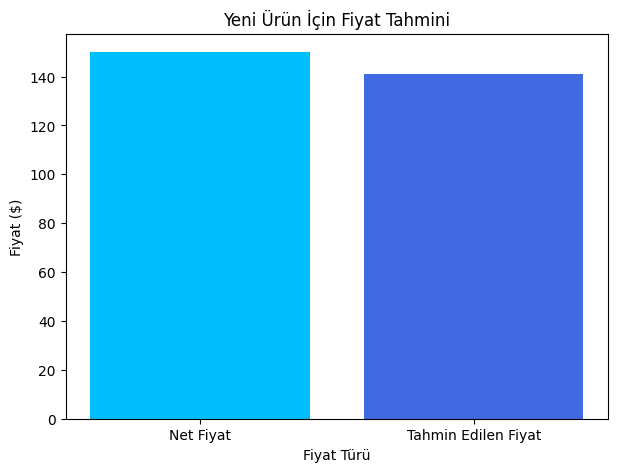

In [40]:
import matplotlib.pyplot as plt

tahmin_df = pd.DataFrame({
    "Değer": ["Net Fiyat", "Tahmin Edilen Fiyat"],
    "Fiyat ($)": [yeni_urun["net fiyat ($)"].iloc[0], tahmin[0]]
})

plt.figure(figsize=(7, 5))

plt.bar(tahmin_df["Değer"], tahmin_df["Fiyat ($)"], color=["deepskyblue", "royalblue"])

plt.title("Yeni Ürün İçin Fiyat Tahmini")
plt.xlabel("Fiyat Türü")
plt.ylabel("Fiyat ($)")

plt.show()